# Spherical Fourier neural operators

This notebook demonstrates how to train a Spherical Fourier Neural Operator (SFNO)
to learn the time evolution of the shallow water equations on the sphere.
The training data is generated on the fly by a spectral PDE solver.

## Preparation

In [2]:
import torch
from torch.utils.data import DataLoader
from torch.cuda import amp

import matplotlib.pyplot as plt

import time
from tqdm.auto import tqdm

cmap='twilight_shifted'

In [3]:
enable_amp = False

# set device
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
if torch.cuda.is_available():
    torch.cuda.set_device(device.index)

### Training data

The `PdeDataset` generates input–target pairs by running a shallow water solver
for a given number of timesteps. Each sample consists of a random initial condition
and its evolved state after `dt` seconds. The data is computed on the fly,
so no pre-existing dataset is required.

In [4]:
# dataset
from torch_harmonics.examples import PdeDataset
from torch_harmonics.examples.models import SphericalFourierNeuralOperator

# 1 hour prediction steps
dt = 1*1800
dt_solver = 100
nsteps = dt//dt_solver
grid = "equiangular"
dataset = PdeDataset(dt=dt, nsteps=nsteps, dims=(241, 480), device=device, normalize=True, grid=grid)
# There is still an issue with parallel dataloading. Do NOT use it at the moment
dataloader = DataLoader(dataset, batch_size=4, shuffle=True, num_workers=0, persistent_workers=False)
solver = dataset.solver.to(device)

nlat = dataset.nlat
nlon = dataset.nlon

Let us visualize a single input–target pair to get a sense of the data:

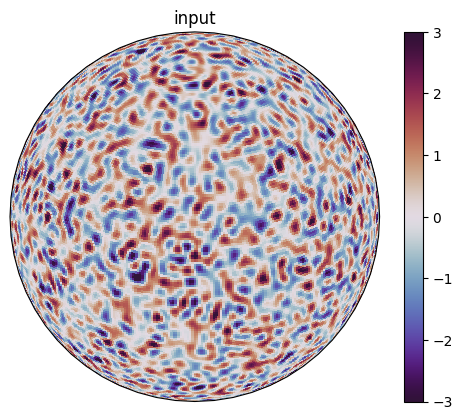

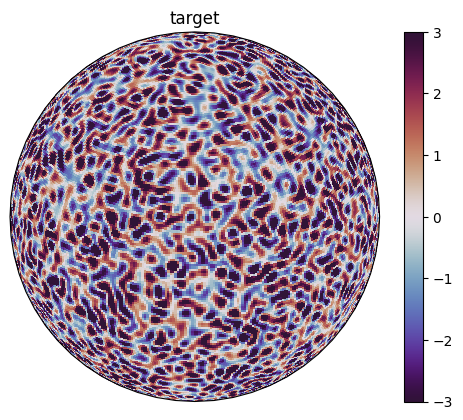

In [5]:
torch.manual_seed(333)
inp, tar = dataset[0]

fig = plt.figure()
im = solver.plot_griddata(inp[2], fig, vmax=3, vmin=-3)
plt.title("input")
plt.colorbar(im)
plt.show()

fig = plt.figure()
im = solver.plot_griddata(tar[2], fig, vmax=3, vmin=-3)
plt.title("target")
plt.colorbar(im)
plt.show()

### Defining the Spherical Neural Operator

The SFNO uses spectral convolutions in the spherical harmonic domain combined
with MLPs in the spatial domain. Key parameters:
- `num_layers`: depth of the network
- `scale_factor`: spectral truncation ratio (controls the number of retained modes)
- `embed_dim`: channel width
- `residual_prediction`: the model predicts the residual (difference between input and target)
- `pos_embed="spectral"`: uses spectral positional embeddings

In [6]:
model = SphericalFourierNeuralOperator(
    img_size=(nlat, nlon),
    grid=grid,
    num_layers=4,
    scale_factor=3,
    embed_dim=16,
    residual_prediction=True,
    pos_embed="spectral",
    use_mlp=True,
    normalization_layer="none",
).to(device)

/home/thorsten/.conda/envs/torch_harmonics/lib/python3.12/site-packages/torch_harmonics/truncation.py:168: UserWarning: Default SHT truncation changed in v0.9.0: equiangular/equiangular-trapezoidal grids now truncate to (nlat+1)//2. Specify lmax explicitly to override.
  lmax = lmax or _truncate_lmax(nlat, grid)


## Training the model

We define two loss functions that operate on the sphere:
- `l2loss_sphere`: computes the $L^2$ error using quadrature weights for proper spherical integration
- `spectral_l2loss_sphere`: computes the $L^2$ error in the spherical harmonic domain via Parseval's theorem

Both support relative error mode (normalizing by the target norm) and can return
either the squared or unsquared loss.

In [7]:
def l2loss_sphere(solver, prd, tar, relative=False, squared=True):
    loss = solver.integrate_grid((prd - tar)**2, dimensionless=True).sum(dim=-1)
    if relative:
        loss = loss / solver.integrate_grid(tar**2, dimensionless=True).sum(dim=-1)

    if not squared:
        loss = torch.sqrt(loss)
    loss = loss.mean()

    return loss

def spectral_l2loss_sphere(solver, prd, tar, relative=False, squared=True):
    # compute coefficients
    coeffs = torch.view_as_real(solver.sht(prd - tar))
    coeffs = coeffs[..., 0]**2 + coeffs[..., 1]**2
    norm2 = coeffs[..., :, 0] + 2 * torch.sum(coeffs[..., :, 1:], dim=-1)
    loss = torch.sum(norm2, dim=(-1,-2))

    if relative:
        tar_coeffs = torch.view_as_real(solver.sht(tar))
        tar_coeffs = tar_coeffs[..., 0]**2 + tar_coeffs[..., 1]**2
        tar_norm2 = tar_coeffs[..., :, 0] + 2 * torch.sum(tar_coeffs[..., :, 1:], dim=-1)
        tar_norm2 = torch.sum(tar_norm2, dim=(-1,-2))
        loss = loss / tar_norm2

    if not squared:
        loss = torch.sqrt(loss)
    loss = loss.mean()

    return loss

In [9]:
# training function
def train_model(model, dataloader, optimizer, scheduler=None, nepochs=20, nfuture=0, num_examples=256, num_valid=8, loss_fn='l2'):

    train_start = time.time()

    pbar = tqdm(range(nepochs), desc="Training")
    for epoch in pbar:

        dataloader.dataset.set_initial_condition('random')
        dataloader.dataset.set_num_examples(num_examples)

        optimizer.zero_grad(set_to_none=True)

        # do the training
        acc_loss = 0
        model.train()
        for inp, tar in dataloader:
            with amp.autocast(enabled=enable_amp):
                prd = model(inp)
                for _ in range(nfuture):
                    prd = model(prd)
                if loss_fn == 'l2':
                    loss = l2loss_sphere(solver, prd, tar)
                elif loss_fn == "spectral l2":
                    loss = spectral_l2loss_sphere(solver, prd, tar)

            acc_loss += loss.item() * inp.size(0)

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            optimizer.step()

        if scheduler is not None:
            scheduler.step()

        acc_loss = acc_loss / len(dataloader.dataset)

        dataloader.dataset.set_initial_condition('random')
        dataloader.dataset.set_num_examples(num_valid)

        # perform validation
        valid_loss = 0
        model.eval()
        with torch.no_grad():
            for inp, tar in dataloader:
                prd = model(inp)
                for _ in range(nfuture):
                    prd = model(prd)
                loss = l2loss_sphere(solver, prd, tar, relative=True)

                valid_loss += loss.item() * inp.size(0)

        valid_loss = valid_loss / len(dataloader.dataset)

        pbar.set_postfix_str(f"train_loss={acc_loss:.4f}, val_loss={valid_loss:.4f}")

    train_time = time.time() - train_start

    print(f'Done. Training took {train_time:.1f}s.')
    return valid_loss

In [10]:
# set seed
torch.manual_seed(333)
torch.cuda.manual_seed(333)

optimizer = torch.optim.Adam(model.parameters(), lr=3E-3, weight_decay=0.0)
gscaler = amp.GradScaler(enabled=enable_amp)
train_model(model, dataloader, optimizer, nepochs=10)

/tmp/ipykernel_364411/3046207757.py:6: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  gscaler = amp.GradScaler(enabled=enable_amp)
Training:   0%|          | 0/10 [00:00<?, ?it/s]/tmp/ipykernel_364411/463415863.py:18: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(enabled=enable_amp):
Training: 100%|██████████| 10/10 [04:49<00:00, 28.99s/it, train_loss=3.7896, val_loss=0.0539] 

Done. Training took 289.9s.


0.05389092490077019

## Inference

Let us visualize the model's predictions on a random sample and compare them
against the ground truth:

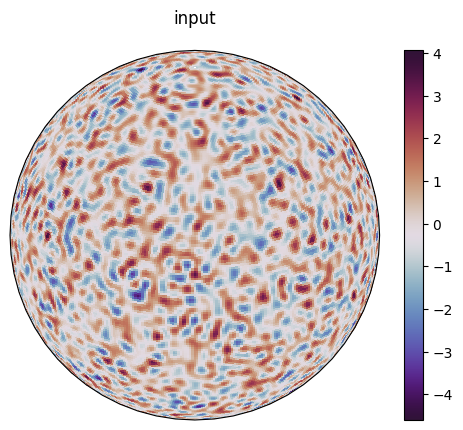

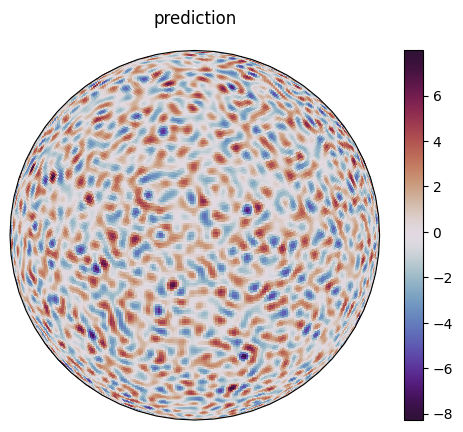

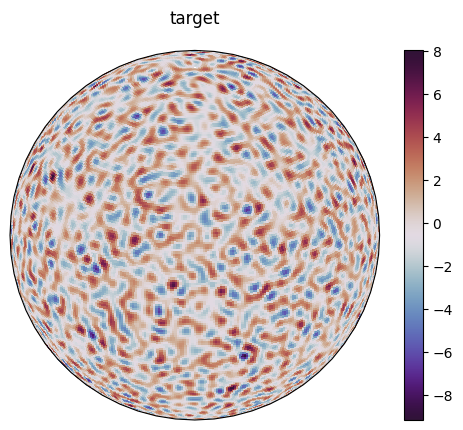

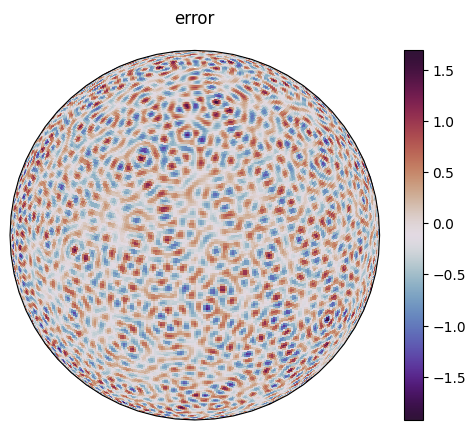

In [11]:
dataloader.dataset.set_initial_condition('random')

torch.manual_seed(333)

with torch.inference_mode():
    inp, tar = next(iter(dataloader))
    out = model(inp).detach()

s = 0; ch = 2

fig = plt.figure()
im = solver.plot_griddata(inp[s, ch], fig, projection='3d', title='input')
plt.colorbar(im)
plt.show()

fig = plt.figure()
im = solver.plot_griddata(out[s, ch], fig, projection='3d', title='prediction')
plt.colorbar(im)
plt.show()

fig = plt.figure()
im = solver.plot_griddata(tar[s, ch], fig, projection='3d', title='target')
plt.colorbar(im)
plt.show()

fig = plt.figure()
im = solver.plot_griddata((tar-out)[s, ch], fig, projection='3d', title='error')
plt.colorbar(im)
plt.show()